# Airline Booking Behavior Analysis

In this project, I explore the factors associated with airline booking completion.

My goal is to understand which booking characteristics appear related to completion behavior, test several hypotheses using statistical methods, and build a baseline machine learning model to evaluate whether booking outcomes can be predicted from the available data.

The project follows a complete analytics workflow including exploratory analysis, hypothesis testing, feature engineering, logistic regression modeling, and business interpretation.

# Loading the dataset

First I want to import pandas and load the dataset before starting the analysis.

In [1]:
import pandas as pd

booking_data = pd.read_csv(r"C:\Users\fergo\OneDrive\Desktop\Porfolios\Airline-Booking-Behavior-Analysis\data\customer_booking.csv",
    encoding='latin1'
)
booking_data.shape

(50000, 14)

The dataset contains 50,000 rows and 14 columns.

# Looking at the first rows

Now I want to inspect the first rows to understand what kind of information is available in the dataset.

In [2]:
booking_data.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


# Understanding the variables

Before starting the analysis, I want to better understand what each variable represents.

In [3]:
booking_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


# Basic statistics

Now I want to look at some basic statistics to better understand the numerical variables.

In [4]:
booking_data.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


# Booking completion rate

Since booking_complete only contains 0s and 1s, I can use mean() to calculate the completion rate.

In [5]:
booking_data['booking_complete'].mean()

np.float64(0.14956)

# First insight

Only around 15% of users actually complete the booking.

That means most people enter the booking process but leave before finishing it. At this point I’m not sure why, but it could mean users are comparing flights, changing their minds, or experiencing some kind of friction during the booking process.

# Booking completion by sales channel

I want to check if the booking completion rate changes depending on the sales channel.

In [6]:
booking_data.groupby('sales_channel')['booking_complete'].mean()

sales_channel
Internet    0.154770
Mobile      0.108402
Name: booking_complete, dtype: float64

# First comparison

Internet bookings seem to convert better than mobile bookings.

Maybe mobile users are just browsing more casually, or maybe completing the booking on mobile is less convenient.

# Number of bookings by sales channel

Now I want to check how many bookings come from each sales channel to better understand the size of each group.

In [8]:
booking_data.groupby('sales_channel')['booking_complete'].count()

sales_channel
Internet    44382
Mobile       5618
Name: booking_complete, dtype: int64

# Sales channel volume

Most bookings come from the Internet channel.

This also explains why the overall booking completion rate was very similar to the Internet completion rate, since Internet bookings represent most of the dataset.

# Optional services and booking completion

I want to check if users who select optional services are more likely to complete the booking.

In [10]:
booking_data.groupby('wants_extra_baggage')['booking_complete'].mean()

wants_extra_baggage
0    0.115029
1    0.166662
Name: booking_complete, dtype: float64

# Extra baggage and booking completion

Users who select extra baggage seem more likely to complete the booking.

The difference is not huge, but it could suggest that users adding optional services are more serious about travelling and less likely to abandon the booking process.

In [11]:
booking_data.groupby('wants_preferred_seat')['booking_complete'].mean()

wants_preferred_seat
0    0.137944
1    0.177061
Name: booking_complete, dtype: float64

In [13]:
booking_data.groupby('wants_in_flight_meals')['booking_complete'].mean()

wants_in_flight_meals
0    0.141396
1    0.160509
Name: booking_complete, dtype: float64

# Optional services and booking completion

All three optional services show a similar pattern.

People who add extra baggage, meals, or preferred seats seem more likely to complete the booking. It looks like users who spend more time customizing the trip are probably more serious about actually travelling.

# Purchase lead and booking completion

Now I want to see if the number of days booked in advance affects the booking completion rate.

<Axes: xlabel='purchase_lead'>

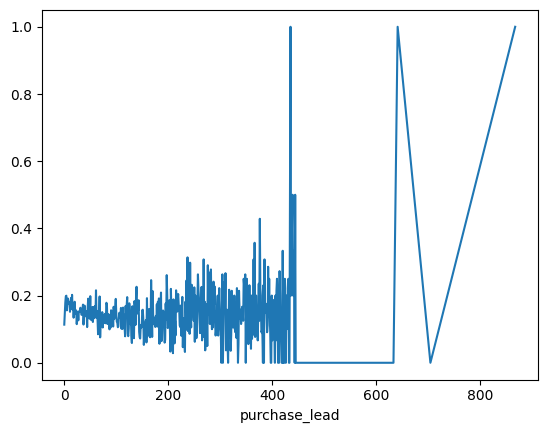

In [14]:
booking_data.groupby('purchase_lead')['booking_complete'].mean().plot()

# Grouping purchase lead into categories

The previous graph was difficult to read because there were too many different purchase_lead values and some groups had very few bookings.

Instead of analyzing every single value, I’m going to group them into larger ranges to make the pattern easier to understand.

In [20]:
booking_data['lead_category'] = pd.cut(booking_data['purchase_lead'], bins=[0, 30, 90, 180, 900], labels=['0-30', '31-90', '91-180', '181+'])

# Checking the new categories

Now I want to check if the new lead categories were created correctly.

In [21]:
booking_data.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,lead_category
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,181+
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,91-180
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,181+
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,91-180
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,31-90


# Booking completion by purchase lead category

The graph using every purchase_lead value was too messy, so grouping the values into ranges should make it easier to see if people booking far in advance behave differently from people booking closer to the flight date.

In [22]:
booking_data.groupby('lead_category')['booking_complete'].mean()

lead_category
0-30      0.165603
31-90     0.145695
91-180    0.133766
181+      0.142125
Name: booking_complete, dtype: float64

# Purchase lead and booking completion

Users booking closer to the flight date seem slightly more likely to complete the booking.

One possible explanation is that people booking far in advance may still be comparing flights or exploring options, while people booking closer to the trip are probably more certain about travelling.

# Most common booking origins

Before comparing booking completion rates by country, I want to see which booking origins appear the most in the dataset.

In [25]:
booking_data['booking_origin'].value_counts()

booking_origin
Australia               17872
Malaysia                 7174
South Korea              4559
Japan                    3885
China                    3387
                        ...  
Ghana                       1
Gibraltar                   1
Guatemala                   1
Algeria                     1
Svalbard & Jan Mayen        1
Name: count, Length: 104, dtype: int64

In [26]:
booking_data['booking_origin'].value_counts().head(10)

booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64

# Top booking origins

There are more than 100 booking origins in the dataset, but many of them only appear a few times.

To avoid misleading results, I’m going to focus on the countries with the highest number of bookings.

In [27]:
top_countries = booking_data['booking_origin'] \
    .value_counts() \
    .head(10) \
    .index

# Filtering the dataset

Now I’m going to keep only the countries with the highest number of bookings so the comparison is more reliable.

In [28]:
top_booking_data = booking_data[
    booking_data['booking_origin'].isin(top_countries)
]

# Booking completion by country

Now I want to compare booking completion rates across the countries with the highest number of bookings.

In [29]:
top_booking_data.groupby('booking_origin')['booking_complete'].mean()

booking_origin
Australia      0.050358
China          0.204901
India          0.103150
Indonesia      0.259603
Japan          0.123037
Malaysia       0.344020
New Zealand    0.050279
South Korea    0.101338
Taiwan         0.107848
Thailand       0.231527
Name: booking_complete, dtype: float64

# Booking completion by country

The completion rate varies a lot depending on the booking origin.

Malaysia, Indonesia, and Thailand have much higher completion rates, while Australia and New Zealand are surprisingly low. There’s probably something different in how users from these countries interact with the booking process, although I still don’t know exactly what is causing it.

# Visualizing booking completion by country

The differences between countries are easier to understand visually, so I’m going to create a simple bar chart.

<Axes: xlabel='booking_origin'>

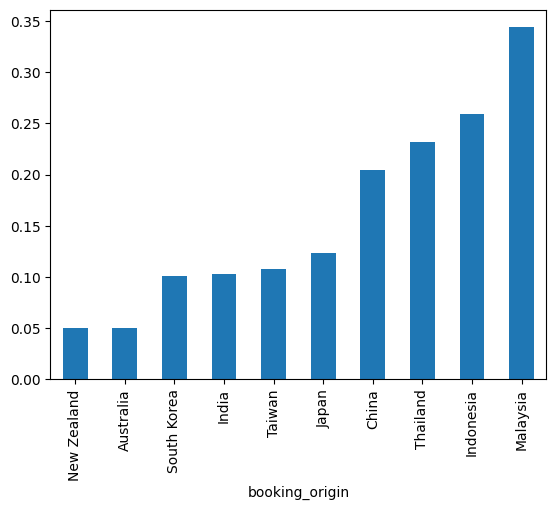

In [30]:
top_booking_data.groupby('booking_origin')[
    'booking_complete'
].mean().sort_values().plot(kind='bar')

# Observation

The differences between countries become much clearer in the chart.

Australia and New Zealand are surprisingly low compared to the rest, while Malaysia and Indonesia stand out with much higher booking completion rates.

# Flight duration and booking completion

Now I want to see if flight duration seems related to booking completion.

In [31]:
booking_data['duration_category'] = pd.cut(
    booking_data['flight_duration'],
    bins=[0, 2, 5, 8, 20],
    labels=['0-2', '2-5', '5-8', '8+']
)

# Checking the new duration categories

Before using the new categories for analysis, I want to make sure they were created correctly.

In [32]:
booking_data['duration_category'].value_counts()

duration_category
8+     22640
5-8    22463
2-5     4897
0-2        0
Name: count, dtype: int64

# Booking completion by flight duration

Now I want to compare booking completion rates across different flight duration ranges.

In [33]:
booking_data.groupby('duration_category')['booking_complete'].mean()

duration_category
2-5    0.263835
5-8    0.167431
8+     0.107111
Name: booking_complete, dtype: float64

# Flight duration and booking completion

Flight duration seems to affect booking completion quite a lot.

Shorter flights have much higher completion rates, while longer flights are completed less often. It could be because longer trips are usually more expensive and require more planning, so users may spend more time comparing options before deciding to book.

# Number of passengers and booking completion

Now I want to see if the number of passengers seems related to booking completion.

In [34]:
booking_data.groupby('num_passengers')['booking_complete'].mean()

num_passengers
1    0.142096
2    0.160184
3    0.166950
4    0.154148
5    0.194296
6    0.186851
7    0.157895
8    0.134831
9    0.196970
Name: booking_complete, dtype: float64

# Number of passengers and booking completion

There doesn’t seem to be a very clear relationship between passenger count and booking completion.

Some group sizes have higher completion rates than others, but the pattern is inconsistent and could simply be caused by smaller sample sizes in the larger groups.

# Distribution of purchase lead

Now I want to look at the distribution of purchase_lead to better understand how far in advance most users book their flights.

<Axes: ylabel='Frequency'>

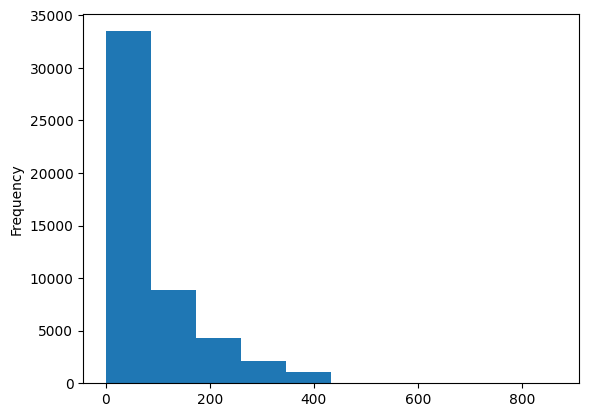

In [35]:
booking_data['purchase_lead'].plot(kind='hist')

# Purchase lead distribution

Most people book relatively close to the flight date.

There are still some users booking very far in advance, but they are much less common. This also explains why the earlier graph looked messy in the extreme values, since there are very few bookings in those ranges.

# Purchase lead boxplot

Now I want to use a boxplot to better understand the spread of purchase_lead values and check for outliers.

<Axes: >

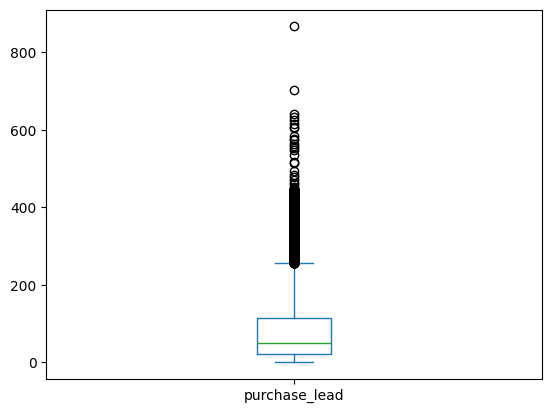

In [37]:
booking_data['purchase_lead'].plot(kind='box')

# Purchase lead boxplot

The boxplot makes it easier to see how concentrated most purchase_lead values are.

Most bookings happen much closer to the flight date, but there are also a lot of extreme values where people book very far in advance.

# Comparing purchase lead by booking outcome

Now I want to compare purchase_lead between completed and non-completed bookings to see if users behave differently.

<Axes: title={'center': 'purchase_lead'}, xlabel='booking_complete'>

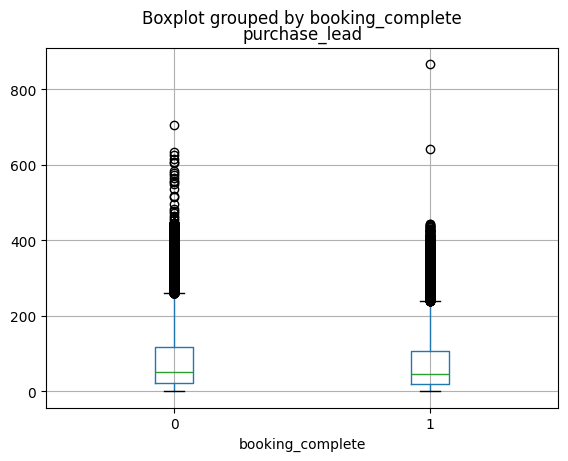

In [38]:
booking_data.boxplot(
    column='purchase_lead',
    by='booking_complete'
)

# Purchase lead by booking outcome

The two distributions look pretty similar overall, although users who completed the booking seem to have a slightly lower purchase_lead on average.

This matches the earlier analysis where bookings closer to the flight date had slightly higher completion rates.

# Correlation analysis

Now I want to check if there are any interesting relationships between the numerical variables in the dataset.

In [40]:
booking_data.corr(numeric_only=True)

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
num_passengers,1.000000,0.212606,-0.115850,0.015607,0.120404,0.028544,0.022943,-0.063169,0.024116
purchase_lead,0.212606,1.000000,-0.076560,0.035973,-0.022207,-0.004499,-0.022653,0.067866,-0.022131
length_of_stay,-0.115850,-0.076560,1.000000,-0.024872,0.176757,0.032264,0.098828,0.141181,-0.042408
flight_hour,0.015607,0.035973,-0.024872,1.000000,-0.011434,0.012171,0.013014,-0.002101,0.007127
wants_extra_baggage,0.120404,-0.022207,0.176757,-0.011434,1.000000,0.207669,0.216470,0.057054,0.068139
wants_preferred_seat,0.028544,-0.004499,0.032264,0.012171,0.207669,1.000000,0.315088,0.101289,0.050116
wants_in_flight_meals,0.022943,-0.022653,0.098828,0.013014,0.216470,0.315088,1.000000,0.154312,0.026511
flight_duration,-0.063169,0.067866,0.141181,-0.002101,0.057054,0.101289,0.154312,1.000000,-0.106266
booking_complete,0.024116,-0.022131,-0.042408,0.007127,0.068139,0.050116,0.026511,-0.106266,1.000000


# Correlation analysis

Most correlations are pretty weak, so there doesn’t seem to be one single variable strongly driving booking completion.

Still, the matrix confirms some of the earlier patterns. Longer flights are slightly associated with lower completion rates, while users selecting optional services seem slightly more likely to complete the booking.

# Flight duration by booking outcome

Since flight duration showed the strongest correlation with booking completion so far, I want to compare the flight duration distributions between completed and non-completed bookings.

<Axes: title={'center': 'flight_duration'}, xlabel='booking_complete'>

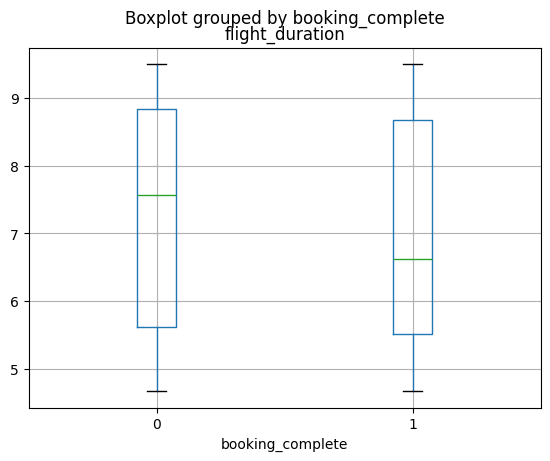

In [41]:
booking_data.boxplot(column='flight_duration', by='booking_complete')

# Flight duration by booking outcome

This chart confirms the pattern seen earlier.

Users who complete the booking tend to choose shorter flights, while users looking at longer flights are less likely to finish the booking. Since the same pattern appeared in the grouped analysis and in the correlation matrix, it seems to be a real relationship rather than random noise.

# Average flight duration by country

I noticed that countries have very different booking completion rates.

Before assuming this is related to the country itself, I want to check whether some countries simply tend to book shorter or longer flights.

In [43]:
top_booking_data.groupby('booking_origin')[
    'flight_duration'
].mean().sort_values()

booking_origin
Taiwan         5.787299
China          5.953912
Indonesia      6.800013
Malaysia       6.885181
South Korea    6.913782
India          7.151622
Thailand       7.343695
Japan          7.369668
Australia      7.968687
New Zealand    8.624590
Name: flight_duration, dtype: float64

# Flight duration by country

I wanted to check if the differences between countries could be partly explained by flight duration.

The countries with the highest booking completion rates generally have shorter average flights, while Australia and New Zealand have the longest average flight durations and some of the lowest completion rates.

Flight duration could be part of the explanation, although it is probably not the only factor affecting booking completion.

In [44]:
booking_data['route'].value_counts().head(10)

route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64


# Route overview

Before analyzing routes, I want to see how many unique routes are included in the dataset.


In [45]:
booking_data['route'].nunique()

799

# Booking completion distribution

Before moving on, I want to visualize the distribution of the target variable and see how balanced the dataset is.

<Axes: xlabel='booking_complete'>

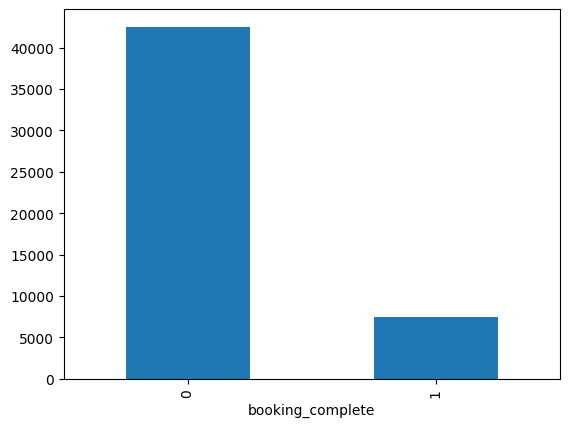

In [46]:
booking_data['booking_complete'].value_counts().plot(kind='bar')

# Booking completion distribution

Just a quick check of the target variable.

Most bookings are not completed, so the dataset is very unbalanced. I'll need to keep this in mind later when evaluating a model because accuracy alone could be misleading.

# Testing the baggage hypothesis

Earlier I found that users who select extra baggage have a higher booking completion rate.

Now I want to check if this difference is large enough to be considered statistically significant, or if it could simply be random variation in the data.

In [47]:
booking_data.groupby('wants_extra_baggage')[
    'booking_complete'
].agg(['count', 'mean'])

,count,mean
wants_extra_baggage,,
0,16561,0.115029
1,33439,0.166662


# Extra baggage and booking completion

The difference between the two groups looks bigger than I expected.

People who select extra baggage complete their booking more often, and both groups are large enough that this probably isn't just a few random observations.

Next I want to test whether the difference is statistically significant or if it could still be explained by chance.

# Testing whether the baggage effect is real

I found that users who select extra baggage complete their bookings more often.

The difference looks meaningful, but I haven't checked whether it could simply be random variation. I want to test that before treating it as a real pattern.

# Preparing the data for the test

I found a difference in booking completion between users who selected extra baggage and those who didn't.

Before running any statistical test, I want to organize the data so I can see the number of completed and non-completed bookings in each group.

In [49]:
pd.crosstab(
    booking_data['wants_extra_baggage'],
    booking_data['booking_complete']
)

booking_complete,0,1
wants_extra_baggage,,
0,14656,1905
1,27866,5573


In [52]:
contingency_table = pd.crosstab(
    booking_data['wants_extra_baggage'],
    booking_data['booking_complete']
)

contingency_table

booking_complete,0,1
wants_extra_baggage,,
0,14656,1905
1,27866,5573


# Contingency table

I converted the data into a contingency table so I can compare completed and non-completed bookings across the two baggage groups.

The difference still looks noticeable. Users selecting extra baggage seem to complete bookings more often than users who do not.

# Statistical significance

So far I've only looked at the percentages.

Now I want to check if the difference is large enough that it's unlikely to be random.

In [50]:
from scipy.stats import chi2_contingency

# What I expect before the test

The difference between the groups looks fairly large and both groups contain a lot of observations.

My expectation is that the test will find evidence of a relationship between extra baggage and booking completion.

# Running the statistical test

The contingency table shows the actual counts for each group.

Now I want to test whether the difference between the two completion rates is likely to be real or if it could have happened by chance.

In [53]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 231.73706388226566
P-value: 2.491861960070551e-52


# Testing the baggage hypothesis

The p-value is much smaller than I expected.

At this point, it seems very unlikely that the difference between the two groups is just random noise. There appears to be a real relationship between selecting extra baggage and booking completion.

This doesn't mean that selecting extra baggage causes people to complete the booking. It only tells me that the two variables are related in the data.

# Testing the sales channel hypothesis

Earlier I noticed that bookings coming from the Internet had a higher completion rate than bookings coming from Mobile.

I want to check whether this difference is statistically significant or if it could simply be random variation in the data.

# Creating the sales channel contingency table

I already know that booking completion rates are different across sales channels.

Before running the statistical test, I want to see the actual number of completed and non-completed bookings in each channel.

# Saving intermediate results

I already created a contingency table for extra baggage, so I'm using a more descriptive variable name here.

This makes it easier to keep track of different tests and avoids accidentally overwriting previous results.

In [60]:
pd.crosstab(
    booking_data['sales_channel'],
    booking_data['booking_complete']
)

booking_complete,0,1
sales_channel,,
Internet,37513,6869
Mobile,5009,609


In [62]:
channel_contingency_table = pd.crosstab(
    booking_data['sales_channel'],
    booking_data['booking_complete']
)
channel_contingency_table


booking_complete,0,1
sales_channel,,
Internet,37513,6869
Mobile,5009,609


# Sales channel contingency table

I wanted to look at the actual number of completed and non-completed bookings for each sales channel before running the test.

The pattern still looks similar to what I found earlier. Internet bookings have a higher completion rate than Mobile bookings, although I still need to check whether the difference is statistically significant.

In [63]:
chi2, p_value, dof, expected = chi2_contingency(
    channel_contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 83.93114914857576
P-value: 5.123094421404519e-20


# Interpreting the sales channel test

The p-value is extremely small, so I can reject the null hypothesis.

This suggests that the difference in booking completion between Internet and Mobile bookings is unlikely to be random. There appears to be a real relationship between sales channel and booking completion.

Just like with the baggage test, this does not prove causation. It only tells me that the two variables are associated in the data.

# Questioning the baggage result

I found that users who select extra baggage have higher booking completion rates.

However, I'm not convinced that baggage is the reason. It could be that longer flights naturally require more baggage, and flight duration is actually driving part of the relationship.

I want to check whether users on longer flights are more likely to select extra baggage.

# Checking the relationship between baggage and flight duration

I started wondering whether the baggage result is actually being influenced by flight duration.

My intuition is that people on longer flights may be more likely to purchase extra baggage, so I want to compare the flight duration distributions between the two baggage groups.

<Axes: title={'center': 'flight_duration'}, xlabel='wants_extra_baggage'>

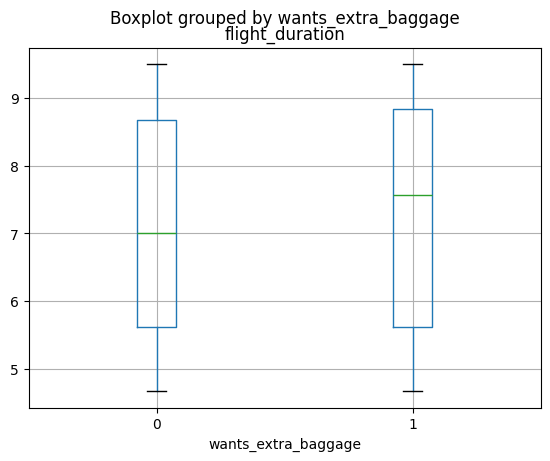

In [64]:
booking_data.boxplot(
    column='flight_duration',
    by='wants_extra_baggage'
)

# Flight duration and extra baggage

The boxplot supports the idea that users on longer flights are more likely to select extra baggage.

The median flight duration is higher for the baggage group, which makes sense intuitively since longer trips may require more luggage.

This makes me wonder whether part of the relationship between extra baggage and booking completion is actually being influenced by flight duration.

In [65]:
booking_data.groupby('duration_category')[
    'wants_extra_baggage'
].mean()

duration_category
2-5    0.686339
5-8    0.620754
8+     0.712633
Name: wants_extra_baggage, dtype: float64

# Does flight duration explain the baggage effect?

I expected to see baggage purchases increase steadily as flight duration increased, but the pattern isn't that clean.

The longest flights do have the highest baggage purchase rate, which supports part of my hypothesis. However, the shortest flights have a higher baggage rate than the medium-length flights.

Flight duration may explain some of the relationship between baggage and booking completion, but it probably doesn't explain all of it.

# Checking the baggage effect within each duration group

Flight duration doesn't fully explain the baggage pattern.

I want to compare booking completion rates for baggage and non-baggage users within each duration category to see if the relationship still exists after accounting for flight duration.

In [66]:
booking_data.groupby(
    ['duration_category', 'wants_extra_baggage']
)['booking_complete'].mean()

duration_category  wants_extra_baggage
2-5                0                      0.200521
                   1                      0.292770
5-8                0                      0.123606
                   1                      0.194205
8+                 0                      0.083615
                   1                      0.116586
Name: booking_complete, dtype: float64

# Checking if flight duration explains the baggage effect

At first I thought the relationship between extra baggage and booking completion might be explained by flight duration.

The idea was that people on longer flights may be more prepared for their trip and therefore more likely to purchase extra baggage.

After splitting the data by flight duration, the pattern still remains. In every duration category, users who select extra baggage have higher booking completion rates than users who don't.

This doesn't prove that extra baggage causes higher completion rates, but it does suggest that flight duration alone is not enough to explain the relationship.

# Checking the preferred seat effect

Earlier I found that users who select a preferred seat have higher booking completion rates.

Before moving on to modeling, I want to check whether this relationship still exists after accounting for flight duration, just like I did with extra baggage.

# What I expect

My guess is that users on longer flights may be more likely to select a preferred seat, since seat comfort probably becomes more important as flight duration increases.

<Axes: title={'center': 'flight_duration'}, xlabel='wants_preferred_seat'>

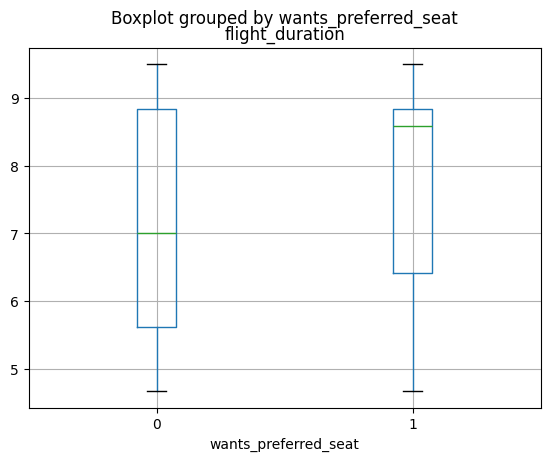

In [67]:
booking_data.boxplot(
    column='flight_duration',
    by='wants_preferred_seat'
)

# Flight duration and preferred seats

The relationship looks stronger than I expected.

Users who select a preferred seat tend to have longer flights on average, which makes sense since seat comfort is probably more important on longer trips.

This makes me wonder whether part of the relationship between preferred seats and booking completion is being influenced by flight duration, just like I suspected with extra baggage.

# Checking if the preferred seat effect remains

I found that users who select a preferred seat tend to have longer flights.

Now I want to see if the higher booking completion rate still exists after splitting the data by flight duration.

In [68]:
booking_data.groupby(
    ['duration_category', 'wants_preferred_seat']
)['booking_complete'].mean()

duration_category  wants_preferred_seat
2-5                0                       0.248826
                   1                       0.335294
5-8                0                       0.148511
                   1                       0.215801
8+                 0                       0.096537
                   1                       0.127701
Name: booking_complete, dtype: float64

# Controlling for flight duration

I thought the relationship between preferred seats and booking completion might be explained by flight duration, since users selecting preferred seats tend to have longer flights.

After splitting the data by duration category, the pattern still remains. In every flight duration group, users who selected a preferred seat had higher booking completion rates than users who did not.

This suggests that flight duration alone does not explain the relationship between preferred seats and booking completion.

# Early hypothesis

The optional services seem to be acting as a signal of purchase intent.

Users who select extras such as baggage or preferred seats may already be more committed to completing the booking than users who are simply browsing.

# Checking the meal effect

I found similar patterns for extra baggage and preferred seats, so I want to see if in-flight meals behave the same way.

My guess is that users selecting meals may also be more committed to the booking process, but I want to check if the relationship remains after accounting for flight duration.

<Axes: title={'center': 'flight_duration'}, xlabel='wants_in_flight_meals'>

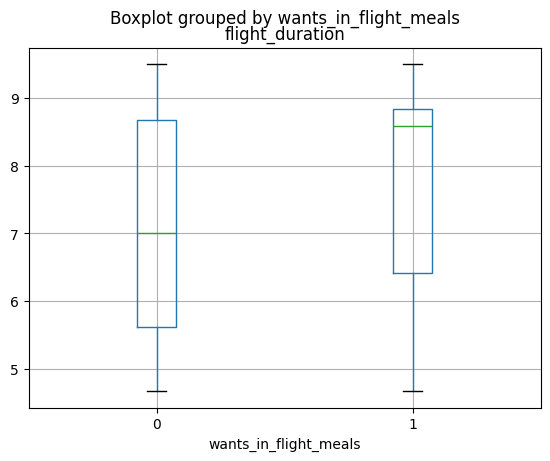

In [69]:
booking_data.boxplot(
    column='flight_duration',
    by='wants_in_flight_meals'
)

# Flight duration and in-flight meals

The relationship looks quite strong.

Users who select in-flight meals tend to have longer flights on average, which makes sense since meals become more relevant as flight duration increases.

This makes me wonder whether the higher booking completion rate for users selecting meals is partly explained by the fact that they are taking longer flights.

# Checking if the meal effect remains

Users selecting meals tend to have longer flights, so flight duration could be influencing the relationship with booking completion.

I want to compare booking completion rates within each duration category to see if the meal effect still appears after accounting for flight duration.

In [70]:
booking_data.groupby(
    ['duration_category', 'wants_in_flight_meals']
)['booking_complete'].mean()

duration_category  wants_in_flight_meals
2-5                0                        0.248258
                   1                        0.300757
5-8                0                        0.149191
                   1                        0.198837
8+                 0                        0.097825
                   1                        0.115870
Name: booking_complete, dtype: float64

# Controlling for flight duration

I found the same pattern again with in-flight meals.

Even after splitting the data by flight duration, users who selected meals had higher booking completion rates than users who did not.

At this point, all three optional services show a similar relationship with booking completion. This makes me think that selecting optional services may be acting as a signal that a customer is more committed to completing the booking.

# Wrapping up the exploratory analysis

At this point I have a much better understanding of the variables that seem related to booking completion.

Flight duration, booking origin, sales channel, and the optional services all show meaningful relationships with the target variable. Instead of continuing to analyze variables one by one, I want to look at all of them together and see which ones remain important when considered at the same time.

# Why I want to build a model

So far I've looked at variables one by one and found several relationships with booking completion.

The problem is that many of these variables are related to each other. A model will allow me to evaluate them together and see which ones still seem important after accounting for the others.

# Preparing the data for modeling

I've finished most of the exploratory analysis and identified several variables that seem related to booking completion.

Before training a model, I need to prepare the data and convert any categorical variables into a format that the model can understand.

In [71]:
booking_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   num_passengers         50000 non-null  int64   
 1   sales_channel          50000 non-null  str     
 2   trip_type              50000 non-null  str     
 3   purchase_lead          50000 non-null  int64   
 4   length_of_stay         50000 non-null  int64   
 5   flight_hour            50000 non-null  int64   
 6   flight_day             50000 non-null  str     
 7   route                  50000 non-null  str     
 8   booking_origin         50000 non-null  str     
 9   wants_extra_baggage    50000 non-null  int64   
 10  wants_preferred_seat   50000 non-null  int64   
 11  wants_in_flight_meals  50000 non-null  int64   
 12  flight_duration        50000 non-null  float64 
 13  booking_complete       50000 non-null  int64   
 14  lead_category          49630 non-null  category
 

# Thinking about the variables before modeling

Before building a model, I want to think about which variables might cause problems.

Some categorical variables have a very large number of unique values. Route stands out because there are almost 800 different routes, which could make the dataset much more complex once the categories are converted into numerical features.

# Choosing the variables for the first model

Before training a model, I want to keep the first version relatively simple.

Some variables have a very large number of unique values, such as route and booking_origin. These may contain useful information, but they also add a lot of complexity.

For the first model, I want to focus on the variables that already showed meaningful relationships with booking completion during the exploratory analysis.

# Getting the data ready for the model

I've already explored the main variables individually and have a rough idea of which ones seem important.

The next step is to prepare the data for the model. I need to separate the outcome I'm trying to predict from the variables that might help explain it.

I'm trying to predict whether a booking gets completed, so `booking_complete` will be the target. The other selected variables will be used as inputs for the model.

In [72]:
y = booking_data['booking_complete']

In [74]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: booking_complete, dtype: int64

In [73]:
X = booking_data[
    [
        'num_passengers',
        'sales_channel',
        'trip_type',
        'purchase_lead',
        'length_of_stay',
        'flight_hour',
        'wants_extra_baggage',
        'wants_preferred_seat',
        'wants_in_flight_meals',
        'flight_duration'
    ]
]

In [75]:
X.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
0,2,Internet,RoundTrip,262,19,7,1,0,0,5.52
1,1,Internet,RoundTrip,112,20,3,0,0,0,5.52
2,2,Internet,RoundTrip,243,22,17,1,1,0,5.52
3,1,Internet,RoundTrip,96,31,4,0,0,1,5.52
4,2,Internet,RoundTrip,68,22,15,1,0,1,5.52


# Looking at the model inputs

Before training the model, I want to inspect the selected variables and make sure they are in a format the model can use.

Some of the variables are already numerical, but others are still stored as text and will need to be converted before training.


# Looking at the model inputs

Before training the model, I want to inspect the selected variables and make sure they are in a format the model can use.

Some of the variables are already numerical, but others are still stored as text and will need to be converted before training.

In [77]:
X.select_dtypes(include='str').columns

Index(['sales_channel', 'trip_type'], dtype='str')

# Encoding the text variables

Only `sales_channel` and `trip_type` are still stored as text.

Before training the model, I need to convert these columns into numerical variables so the model can use them.

In [78]:
X_encoded = pd.get_dummies(
    X,
    columns=['sales_channel', 'trip_type'],
    drop_first=True
)

X_encoded.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,sales_channel_Mobile,trip_type_OneWay,trip_type_RoundTrip
0,2,262,19,7,1,0,0,5.52,False,False,True
1,1,112,20,3,0,0,0,5.52,False,False,True
2,2,243,22,17,1,1,0,5.52,False,False,True
3,1,96,31,4,0,0,1,5.52,False,False,True
4,2,68,22,15,1,0,1,5.52,False,False,True


In [79]:
booking_data['trip_type'].value_counts()

trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

# Understanding the encoded columns

The new columns created by one-hot encoding can be interpreted as simple yes/no questions.

For example, `sales_channel_Mobile` asks whether a booking came from the Mobile channel. A value of True means yes, while False means no.

When a category is dropped using `drop_first=True`, the missing category becomes the reference category. In this case, if `sales_channel_Mobile` is False, the booking must belong to the Internet channel.

In [80]:
X_encoded.dtypes

num_passengers             int64
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
sales_channel_Mobile        bool
trip_type_OneWay            bool
trip_type_RoundTrip         bool
dtype: object

# Checking the final data types

The encoded variables were created as boolean columns rather than integers.

This is fine because the model can interpret True and False as binary values. At this point, all selected features are stored in a format that can be used for training.

# Creating training and test datasets

I want to evaluate the model on data it has never seen before.

To do that, I'll split the dataset into a training set and a test set. The training data will be used to learn patterns, while the test data will be used to check how well those patterns generalize to new bookings.

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
X_test.shape


(10000, 11)

# Verifying the split

The test dataset contains 10,000 bookings and 11 input features.

This confirms that the split worked correctly and that the model will be evaluated on a separate set of bookings that were not used during training.

In [86]:
X_train.shape

(40000, 11)

# Checking the train-test split

Everything looks as expected.

Most of the data will be used to train the model, while a smaller portion will be kept aside for testing. This should give me a more realistic idea of how well the model performs on new bookings instead of just measuring how well it remembers the training data.

The dataset is now ready for the first modeling step.

# Building the first model

I've already identified a few variables that seem important, such as flight duration, sales channel and the optional services.

Instead of looking at them separately, I want to see how they behave together. My goal here isn't to build the best possible model yet, but to get a first idea of which variables still matter once everything is considered at the same time.

In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
model = LogisticRegression(max_iter=1000)

# Creating the model

I'm starting with a Logistic Regression model as a baseline.

At this stage, I mainly want to understand how the model behaves and which variables appear to be important. The model is allowed up to 1000 iterations to make sure it has enough time to converge during training.

In [89]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# First predictions

The model is now trained.

I'm curious to see how it performs on the test data, since these are bookings that were not used during training.

My goal here is to check whether the patterns learned from the training data can generalize to new bookings.

In [90]:
y_pred = model.predict(X_test)

# Making the first predictions

I've trained the model using the training data, so now I want to see what it does with completely new bookings.

Up to this point, I've found several patterns in the data, but I don't know yet whether those patterns are actually useful for prediction.

The goal of this step is to generate the model's predictions and start comparing them with the real outcomes.

In [94]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Looking at the model's probabilities

Something doesn't look right yet.

The model is predicting only 0s, which initially made me think there might be a problem with the training process.

Before assuming the model is broken, I want to check the predicted probabilities. Since booking completion is relatively uncommon in this dataset, it's possible that the model is assigning different probabilities to each booking but keeping all of them below the default classification threshold.

In [96]:
model.predict_proba(X_test)[:10]

array([[0.77758894, 0.22241106],
       [0.92852917, 0.07147083],
       [0.88685557, 0.11314443],
       [0.78979585, 0.21020415],
       [0.81642494, 0.18357506],
       [0.78425473, 0.21574527],
       [0.83763945, 0.16236055],
       [0.81188497, 0.18811503],
       [0.88286027, 0.11713973],
       [0.91888234, 0.08111766]])

# Looking at the predicted probabilities

Something looked strange when I saw that the model was predicting only 0s.

After checking the predicted probabilities, I can see that the model is not treating every booking the same. Different bookings are receiving different completion probabilities.

The reason I'm only getting 0s from `predict()` is that all of these probabilities are below the default 50% classification threshold. This suggests that the model has learned some patterns, but it currently considers these bookings more likely to be incomplete than complete.

Before evaluating the model, I want to understand the range of probabilities the model is producing across the entire test set.

In [97]:
model.predict_proba(X_test)[:, 1].max()

np.float64(0.37704080961546327)

# Understanding why the model predicts only 0s

At first I thought something might be wrong because the model was predicting only 0s.

After looking at the predicted probabilities, I found that the highest completion probability in the entire test set is only about 38%.

Since the default classification threshold is 50%, none of the bookings are being classified as completed. This explains why `predict()` returns only 0s even though the model is assigning different probabilities to different bookings.

At this point, I don't think the model is broken. Instead, it seems that booking completion is rare enough that the model never becomes confident enough to cross the default threshold.

How many completed bookings are actually in the test set?

In [98]:
y_test.mean()

np.float64(0.148)

# Checking the class balance in the test set

I wanted to confirm whether the test data has a similar completion rate to the full dataset.

The completion rate is about 15%, which means most bookings are not completed. This helps explain why the model is being very conservative and assigning relatively low completion probabilities.

At this point, I'm starting to see that predicting booking completion may be challenging because the positive class is much less common than the negative class.

# Why accuracy can be misleading

At first, accuracy seems like a natural metric to evaluate the model.

However, the dataset is highly imbalanced. Since about 85% of bookings are not completed, a model that predicts "not completed" for every booking would achieve roughly 85% accuracy without learning anything useful.

This means that a high accuracy score alone does not necessarily indicate a good model. I need to look at other metrics that evaluate how well the model identifies completed bookings.

In [99]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.852

# Interpreting the accuracy score

The model achieved an accuracy of about 85%, which initially sounds very good.

However, I already know that the model is predicting only the negative class. Since roughly 85% of the bookings are not completed, the model can achieve this score simply by predicting "not completed" for every booking.

This is a good reminder that accuracy alone can be misleading when the classes are imbalanced. Even though the score is high, the model is currently failing to identify completed bookings.

# Looking beyond accuracy

The accuracy score doesn't tell me which types of mistakes the model is making.

I want to look at the confusion matrix because it shows how many bookings were correctly and incorrectly classified in each category. This should make it easier to understand whether the model is actually identifying completed bookings or simply predicting the majority class.

In [100]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[8520,    0],
       [1480,    0]])

# Interpreting the confusion matrix

The confusion matrix confirms what I suspected after looking at the predictions.

The model correctly identified 8,520 bookings that were not completed, but it failed to identify a single completed booking.

All 1,480 completed bookings were classified as not completed.

This explains why the accuracy looked high despite the model performing poorly on the class I'm actually interested in understanding. The model is heavily biased toward predicting the majority class.

# What I've learned so far

The model is not completely useless because it has learned patterns and produces different probabilities for different bookings.

However, the default classification threshold causes every booking to be classified as not completed.

At this point, I need metrics that focus on how well the model identifies completed bookings rather than relying only on overall accuracy.

# Looking beyond accuracy

The confusion matrix showed that the model failed to identify a single completed booking.

Even though the accuracy was around 85%, the model is not helping me find the bookings that actually complete.

At this point, I need metrics that focus on the completed bookings rather than treating all predictions equally. My goal is to understand how well the model identifies the positive class and where it is making mistakes.

# Understanding recall

I can think of recall as the model's ability to find the bookings that actually complete.

The question recall answers is:

"Of all the completed bookings, how many did the model correctly identify?"

Since the model failed to identify any completed bookings, I expect the recall score to be extremely low.

In [101]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.0

# Understanding precision

Recall focuses on how many completed bookings I managed to find.

Precision looks at the problem from the opposite direction. Instead of asking how many completed bookings were found, it asks whether the bookings predicted as completed were actually completed.

I'm curious to see what happens in this case because the model never predicts the positive class.

In [102]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

c:\Users\fergo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.0

# Calculating precision

The precision score is also 0.

This happened because the model never predicted a completed booking. As a result, there are no positive predictions to evaluate.

From a practical perspective, a precision of 0 reinforces the same conclusion as recall: the model is currently not identifying any completed bookings, so it is not useful for distinguishing between completed and incomplete bookings.

# What I've learned from the first model

The first model helped me understand why evaluating a classification model requires more than a single metric.

At first, the accuracy score looked strong, but the confusion matrix revealed that the model was predicting only the majority class.

The recall and precision scores confirmed that the model failed to identify completed bookings. This tells me that the model is learning some patterns, but the default decision threshold is causing all bookings to be classified as not completed.

# Deciding where to go next

At this point, I could spend a lot of time trying to improve the model, tune parameters, or test different algorithms.

However, this is a portfolio project, so my main goal is to demonstrate a complete analytical workflow rather than achieve the highest possible predictive performance.

I already explored the data, tested several hypotheses, trained a baseline model, and learned that accuracy can be misleading in an imbalanced classification problem.

Before trying more complex models, I want to understand what this model has learned and which variables are influencing its predictions.

In [103]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})

coef_df.sort_values('coefficient', ascending=False)

,feature,coefficient
10,trip_type_RoundTrip,1.056633
4,wants_extra_baggage,0.411835
5,wants_preferred_seat,0.260955
6,wants_in_flight_meals,0.113855
0,num_passengers,0.033302
3,flight_hour,0.004674
1,purchase_lead,-0.000535
2,length_of_stay,-0.005232
9,trip_type_OneWay,-0.018719
7,flight_duration,-0.194456


# Looking at what the model learned

At this point, I'm less interested in the overall prediction performance and more interested in understanding which variables are influencing the model.

The coefficients tell me whether a variable pushes the prediction toward booking completion or toward booking abandonment.

I need to be careful not to interpret these as causal relationships. A positive coefficient does not necessarily mean that the variable causes bookings to complete. It only means that, after accounting for the other variables in the model, the variable is associated with a higher probability of completion.

# Comparing the coefficients with the EDA findings

One thing I find encouraging is that several of the strongest coefficients match patterns I observed during the exploratory analysis.

Extra baggage, preferred seats and in-flight meals all have positive coefficients, while mobile bookings and longer flight durations have negative coefficients.

This gives me more confidence that the relationships I observed during the EDA are not just random patterns in isolated comparisons.

trip_type_RoundTrip = 1.06
I want to check whether RoundTrip bookings have a much higher completion rate than OneWay and CircleTrip bookings.

In [104]:
booking_data.groupby('trip_type')['booking_complete'].mean().sort_values(ascending=False)

trip_type
RoundTrip     0.150575
OneWay        0.051680
CircleTrip    0.043103
Name: booking_complete, dtype: float64

# Validating the strongest model coefficient

The largest positive coefficient in the model belonged to RoundTrip bookings, so I wanted to verify whether this relationship was visible in the raw data.

The completion rates show a very large difference between trip types. RoundTrip bookings have a completion rate of about 15%, while OneWay and CircleTrip bookings are both close to 5%.

This gives me confidence that the model is capturing a real pattern rather than assigning a large coefficient because of random variation.

# Where I am in the project

At this point, I have completed the main analytical workflow.

I explored the data, generated hypotheses, tested several relationships statistically, built a baseline classification model, evaluated its performance, and interpreted the model coefficients.

The model itself is not particularly useful for predicting completed bookings because it defaults to the majority class. However, the exercise helped me identify which variables appear to be most strongly associated with booking completion and reinforced several patterns that were already visible during the exploratory analysis.

For a portfolio project, the most valuable outcome is not the model accuracy but the ability to explain the reasoning, testing process, and insights discovered throughout the analysis.

# Final conclusions

At this point, I want to step back from the individual analyses and focus on the main findings from the project.

The goal is not to summarize every chart or statistical test, but to identify the patterns that consistently appeared throughout the exploratory analysis and the modeling process.

I'm looking for insights that could help explain booking completion behavior and that would be relevant to a business stakeholder.

# Insight 1: Optional services are associated with higher booking completion

One of the most consistent patterns throughout the analysis was the relationship between ancillary purchases and booking completion.

Bookings that included extra baggage, preferred seats, or in-flight meals showed higher completion rates than bookings without these services.

Initially, I suspected that some of these relationships could be explained by other factors such as flight duration. However, these variables continued to show positive coefficients in the logistic regression model, suggesting that the relationship remains even after accounting for other variables.

This does not necessarily mean that purchasing these services causes a booking to be completed, but it does indicate that travelers who select additional services appear to be more committed during the booking process.

# Insight 2: Mobile bookings are less likely to be completed

The sales channel consistently appeared as an important factor.

Bookings made through the mobile channel showed lower completion rates than bookings made through the internet channel. This pattern was visible during the exploratory analysis and was also reflected in the logistic regression coefficients.

This finding could indicate differences in user behavior, booking intent, or the booking experience itself. However, additional information would be needed before concluding why this relationship exists.

# Insight 3: Trip type appears to be one of the strongest predictors

The strongest positive coefficient in the logistic regression model was associated with RoundTrip bookings.

When I examined the raw completion rates, RoundTrip bookings had a completion rate of roughly 15%, compared to approximately 5% for OneWay and CircleTrip bookings.

This suggests that travelers booking round trips may have stronger travel intent and are therefore more likely to complete the booking process.

# Insight 4: Flight duration alone does not explain booking behavior

During the exploratory analysis, I observed that flight duration seemed related to both ancillary purchases and booking completion.

This led me to question whether variables such as extra baggage were simply acting as proxies for longer flights. After incorporating multiple variables into the logistic regression model, flight duration still showed a negative relationship with booking completion, while ancillary services continued to show positive relationships.

This suggests that flight duration is only part of the story and that traveler purchasing behavior contains additional information about booking completion.

# Insight 5: High model accuracy did not translate into useful predictions

The logistic regression model achieved an accuracy of approximately 85%, which initially appeared strong.

However, further evaluation showed that the model predicted only the majority class and failed to identify any completed bookings. The confusion matrix, recall score, and precision score revealed that the model was not useful for detecting the minority class despite its high accuracy.

This was one of the most important lessons from the project because it demonstrated why accuracy alone can be misleading in imbalanced classification problems.

# Final reflection

The most valuable outcome of this project was not building a highly accurate predictive model.

Instead, the project allowed me to practice the complete analytical workflow: exploring the data, generating hypotheses, validating relationships with statistical tests, building a baseline model, evaluating its performance, and interpreting the results.

The analysis identified several variables that appear consistently associated with booking completion, including trip type, ancillary purchases, and sales channel. At the same time, the modeling exercise highlighted the challenges of working with imbalanced classification datasets and the importance of choosing evaluation metrics carefully.

# Potential business recommendations

Based on the patterns observed in the analysis, I can think of a few areas that may deserve further investigation.

These recommendations are exploratory and should not be interpreted as proven solutions. The analysis identified associations rather than causal relationships, so any business action would require additional testing and validation.

# Recommendation 1: Investigate the mobile booking experience

Mobile bookings consistently showed lower completion rates than internet bookings.

I don't have enough information to determine why this happens, but the size and consistency of the relationship suggest that the mobile booking experience may deserve additional investigation.

Possible next steps could include reviewing the booking flow, identifying points of abandonment, or comparing user behavior across channels.

# Recommendation 2: Explore opportunities around ancillary services

Bookings that included extra baggage, preferred seats, or in-flight meals were more likely to be completed.

I cannot conclude that these services cause higher completion rates, but they may serve as indicators of stronger purchase intent.

It could be useful to explore whether travelers can be encouraged to engage with these services earlier in the booking process or whether these selections can be used as signals in future predictive models.

# Recommendation 3: Segment travelers by trip type

RoundTrip bookings showed substantially higher completion rates than OneWay and CircleTrip bookings.

This suggests that traveler intent may differ significantly across trip types.

Future analyses could investigate whether marketing strategies, promotions, or booking experiences should be tailored differently for each segment.

# Limitations of the analysis

While the analysis identified several meaningful patterns, there are important limitations to keep in mind.

The dataset contains only the variables provided and does not include information about pricing, competition, promotions, website behavior, customer demographics, or other factors that could influence booking completion.

Because of this, the results should be interpreted as associations rather than evidence of causation.

The predictive model also struggled with the class imbalance problem, which limited its ability to identify completed bookings despite achieving relatively high accuracy.

# Next steps

If I were continuing this project, I would explore additional data sources such as pricing information, customer demographics, website behavior, and promotional campaigns.

I would also investigate techniques for handling class imbalance and compare logistic regression against other classification models.

However, for the purpose of this project, my goal was to build a complete analytical workflow and understand the factors associated with booking completion rather than maximize predictive performance.